In [3]:
import os
import sys

import tensorflow.compat.v1 as tf

tf.get_logger().setLevel("ERROR")  # only show error messages

from recommenders.utils.timer import Timer
from recommenders.utils.constants import SEED
from recommenders.models.deeprec.deeprec_utils import prepare_hparams
from recommenders.datasets.MG_amazon_reviews import (
    data_preprocessing,
    _create_vocab,
    download_and_extract,
)

from recommenders.models.deeprec.models.sequential.sli_rec import (
    SLI_RECModel as SeqModel,
)

####  to use the other model, use one of the following lines:
# from recommenders.models.deeprec.models.sequential.asvd import A2SVDModel as SeqModel
# from recommenders.models.deeprec.models.sequential.caser import CaserModel as SeqModel
# from recommenders.models.deeprec.models.sequential.gru import GRUModel as SeqModel
# from recommenders.models.deeprec.models.sequential.sum import SUMModel as SeqModel
# from recommenders.models.deeprec.models.sequential.nextitnet import NextItNetModel
from recommenders.models.deeprec.io.sequential_iterator import SequentialIterator

# from recommenders.models.deeprec.io.nextitnet_iterator import NextItNetIterator
from recommenders.utils.notebook_utils import store_metadata

print(f"System version: {sys.version}")
print(f"Tensorflow version: {tf.__version__}")

System version: 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:20:01) [Clang 18.1.8 ]
Tensorflow version: 2.15.1


In [4]:
EPOCHS = 10
BATCH_SIZE = 400
RANDOM_SEED = SEED  # Set None for non-deterministic result

data_path = "../Data/domain_transfer_capabilities/"

##  ATTENTION: change to the corresponding config file, e.g., caser.yaml for CaserModel, sum.yaml for SUMModel
yaml_file = "../Experiments/domain_transfer_capabilities/recommenders/models/deeprec/config/sli_rec.yaml"

## Visualizations 

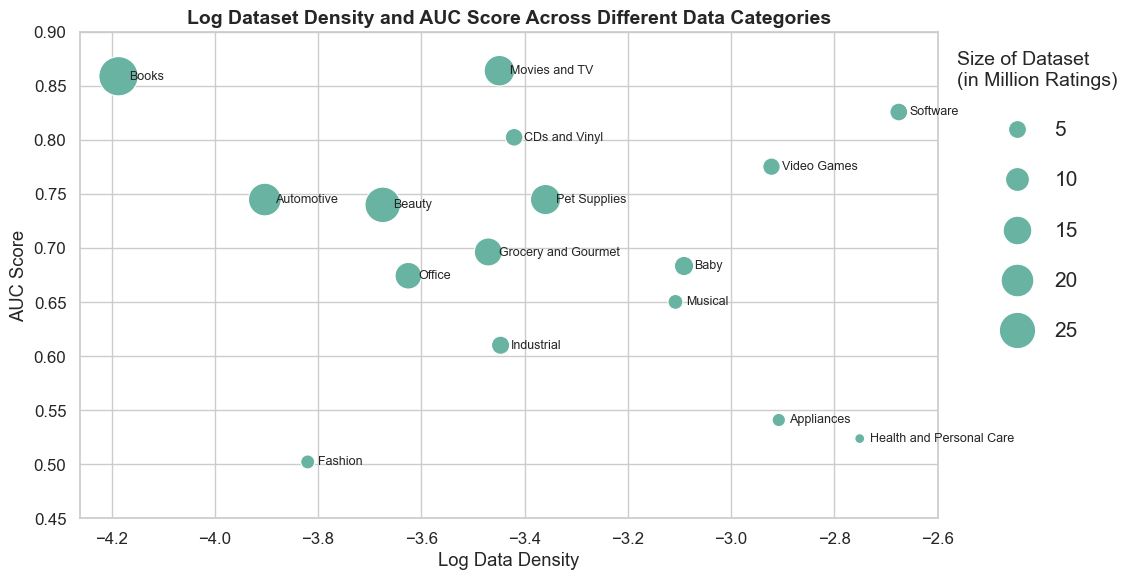

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === Data ===
data = {
    "dataset": [
        "Grocery and Gourmet",
        "Health and Personal Care",
        "Software",
        "Automotive",
        "Pet Supplies",
        "Movies and TV",
        "Appliances",
        "Video Games",
        "Beauty",
        "Books",
        "Baby",
        "Musical",
        "CDs and Vinyl",
        "Office",
        "Industrial",
        "Fashion",
    ],
    "density_rate": [
        0.0003386699507,
        0.001774751971,
        0.002112797516,
        0.000125,
        0.0004371516448,
        0.0003559158146,
        0.001237186285,
        0.001197417743,
        0.0002115044248,
        0.00006509267432,
        0.0008106136345,
        0.0007802746567,
        0.0003800294523,
        0.0002370791844,
        0.0003577571379,
        0.0001513500424,
    ],
    "auc_score": [
        0.6964,
        0.5237,
        0.8259,
        0.7449,
        0.7449,
        0.8641,
        0.5409,
        0.7753,
        0.74,
        0.859,
        0.6834,
        0.6502,
        0.8025,
        0.6744,
        0.6101,
        0.5021,
    ],
    "ratings": [
        14300000,
        494100,
        4900000,
        20000000,
        16800000,
        17300000,
        2100000,
        4600000,
        23900000,
        29500000,
        6000000,
        3000000,
        4800000,
        12800000,
        5200000,
        2500000,
    ],
}

df = pd.DataFrame(data)

# === Data Preprocessing ===
df["log_density"] = np.log10(df["density_rate"])
df["dot_size"] = df["ratings"] / 1000000  # scale down ratings for dot size

highlight_datasets = ["Movies and TV", "CDs and Vinyl"]

# === Plotting ===
sns.set(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 6))

# 👉 1. Base scatter plot: all points in blue
scatter = sns.scatterplot(
    data=df,
    x="log_density",
    y="auc_score",
    size="dot_size",
    sizes=(50, 800),
    color="#69b3a2",  # blue fill
    legend="brief",
    ax=ax,
)

# 👉 2. Highlight datasets separately in salmon
highlight = df[df["dataset"].isin(highlight_datasets)]

# sns.scatterplot(
#     data=highlight,
#     x="log_density",
#     y="auc_score",
#     size="dot_size",  # SAME size scaling as before
#     sizes=(50, 800),
#     c="lightsalmon",  # salmon fill
#     edgecolor="black",  # optional: small black border
#     linewidth=0.5,
#     legend=False,
#     ax=ax,
# )

# 👉 3. Annotate all points
for i in range(df.shape[0]):
    ax.text(
        df["log_density"][i] + 0.02,
        df["auc_score"][i],
        df["dataset"][i],
        fontsize=9,
        va="center",
    )

# 👉 4. Labels and legend adjustments
ax.set_title(
    "Log Dataset Density and AUC Score Across Different Data Categories",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Log Data Density")
ax.set_ylabel("AUC Score")
ax.set_ylim(0.45, 0.9)

# Shrink plot and move legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Size of Dataset\n(in Million Ratings)",
    frameon=False,
    ncol=1,
    labelspacing=1.5,
    handleheight=0.5,
    fontsize=15,
)
legend.get_title().set_fontsize(14)

plt.tight_layout()
plt.show()

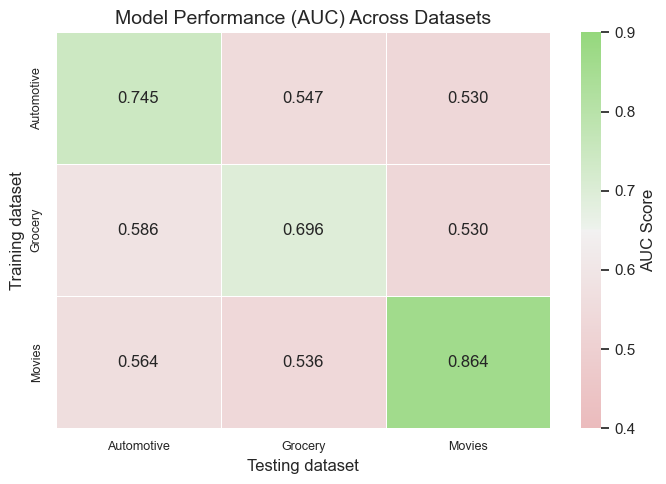

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create the DataFrame
data = {
    "Source": [
        "Grocery",
        "Movies",
        "Automotive",
        "Automotive",
        "Grocery",
        "Movies",
        "Automotive",
        "Movies",
        "Grocery",
    ],
    "Target": [
        "Movies",
        "Grocery",
        "Movies",
        "Grocery",
        "Automotive",
        "Automotive",
        "Automotive",
        "Movies",
        "Grocery",
    ],
    "Value": [0.5304, 0.5362, 0.5303, 0.5468, 0.5864, 0.5639, 0.7449, 0.8641, 0.6964],
}

df = pd.DataFrame(data)

# Step 2: Pivot the DataFrame
heatmap_data = df.pivot(index="Source", columns="Target", values="Value")

# Step 3: Create the soft pastel red-to-green colormap
soft_cmap = sns.diverging_palette(
    h_neg=10,  # red hue
    h_pos=120,  # green hue
    s=60,  # saturation
    l=80,  # lightness
    as_cmap=True,
)

# Step 4: Plot
plt.figure(figsize=(7, 5))
sns.set_theme(style="white")

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap=soft_cmap,
    linewidths=0.5,
    cbar_kws={"label": "AUC Score"},
    vmin=0.4,  # Set min/max for colorbar to match your style
    vmax=0.9,
)

plt.title("Model Performance (AUC Score) Across Datasets", fontsize=14)
plt.ylabel("Training dataset", fontsize=12)
plt.xlabel("Testing dataset", fontsize=12)

# Axis label formatting
plt.xticks(fontsize=9, rotation=0)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

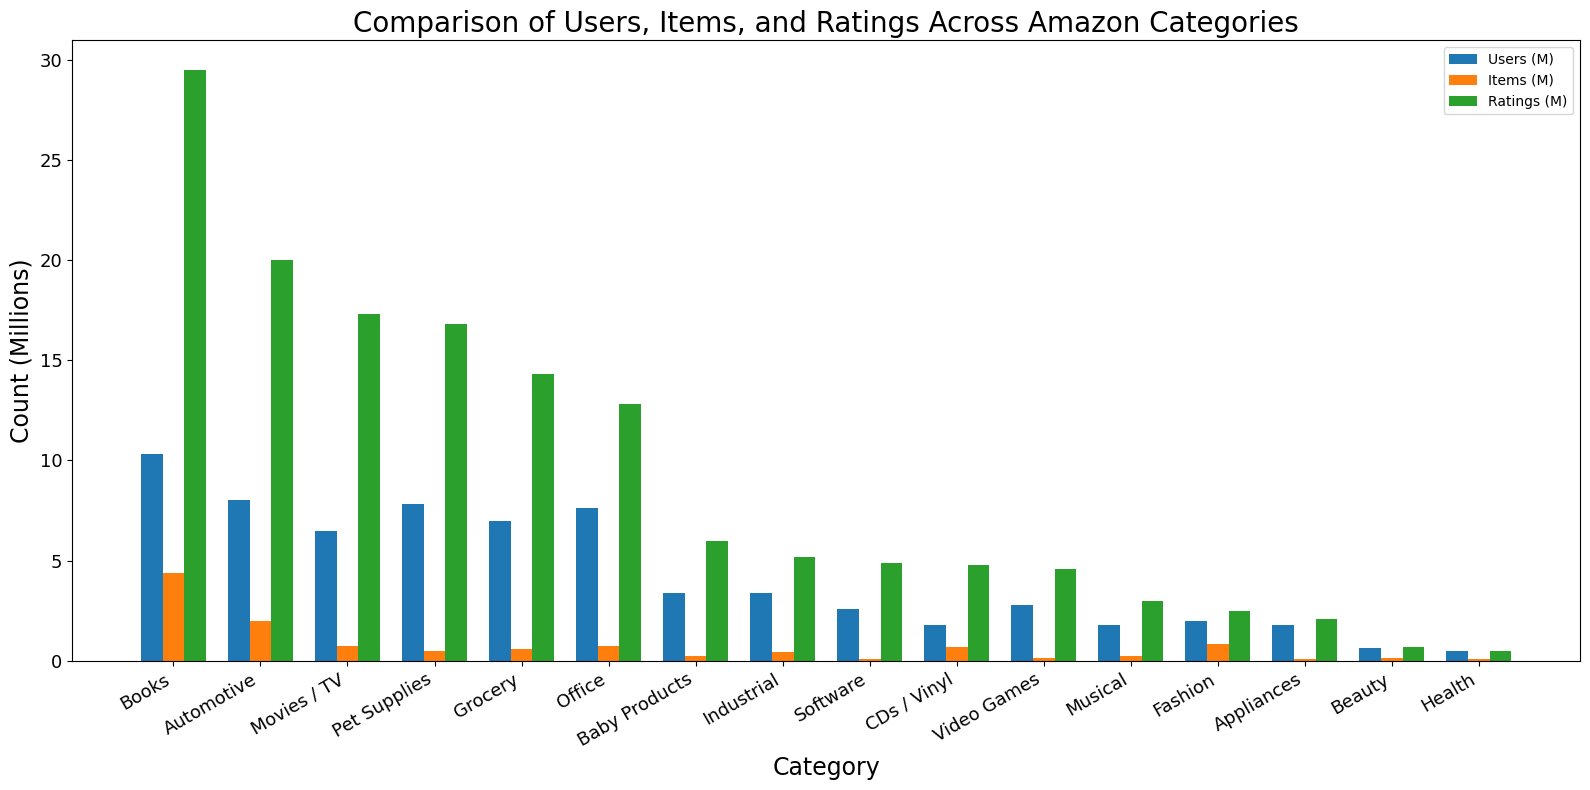

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
data = {
    "Category": [
        "Grocery",
        "Health",
        "Software",
        "Automotive",
        "Pet Supplies",
        "Movies / TV",
        "Appliances",
        "Video Games",
        "Beauty",
        "Books",
        "Baby Products",
        "Musical",
        "CDs / Vinyl",
        "Office",
        "Industrial",
        "Fashion",
    ],
    "Number of Users": [
        7000000,
        461700,
        2600000,
        8000000,
        7800000,
        6500000,
        1800000,
        2800000,
        632000,
        10300000,
        3400000,
        1800000,
        1800000,
        7600000,
        3400000,
        2000000,
    ],
    "Number of Items": [
        603200,
        60300,
        89200,
        2000000,
        492700,
        747800,
        94300,
        137200,
        112600,
        4400000,
        217700,
        213600,
        701700,
        710400,
        427500,
        825900,
    ],
    "Number of Ratings": [
        14300000,
        494100,
        4900000,
        20000000,
        16800000,
        17300000,
        2100000,
        4600000,
        701500,
        29500000,
        6000000,
        3000000,
        4800000,
        12800000,
        5200000,
        2500000,
    ],
}

# Create DataFrame
df = pd.DataFrame(data)

# Convert to millions
df["Number of Users"] = df["Number of Users"] / 1_000_000
df["Number of Items"] = df["Number of Items"] / 1_000_000
df["Number of Ratings"] = df["Number of Ratings"] / 1_000_000

# Sort by Number of Ratings (descending)
df = df.sort_values("Number of Ratings", ascending=False)

# Set figure size
plt.figure(figsize=(16, 8))

# Plot
categories = df["Category"]
x = range(len(categories))

plt.bar(x, df["Number of Users"], width=0.25, label="Users (M)")
plt.bar([i + 0.25 for i in x], df["Number of Items"], width=0.25, label="Items (M)")
plt.bar([i + 0.5 for i in x], df["Number of Ratings"], width=0.25, label="Ratings (M)")

# Add labels
plt.xlabel("Category", fontsize=17)
plt.ylabel("Count (Millions)", fontsize=17)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.title(
    "Comparison of Users, Items, and Ratings Across Amazon Categories", fontsize=20
)
plt.xticks([i + 0.25 for i in x], categories, rotation=30, ha="right")
plt.subplots_adjust(bottom=0.25)
plt.legend()

plt.tight_layout()
plt.show()